downloads moroccan stock prices dataset from kaggle

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aymanlafaz/moroccan-stock-prices")

print("Path to dataset files:", path)

Path to dataset files: /Users/mac/.cache/kagglehub/datasets/aymanlafaz/moroccan-stock-prices/versions/1


In [28]:
import pandas as pd

df = pd.read_csv(path+"/stocks.csv")
prices = df["MASI"].values.reshape((-1, 1))

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)


In [39]:
import numpy as np

#how many days we will use to predict the next day
timesteps = 3

X, Y = [], []

for i in range(timesteps, len(scaled_prices)):
    X.append(scaled_prices[i-timesteps:i])
    Y.append(scaled_prices[i])

X, Y = np.array(X), np.array(Y)

X = X.reshape(X.shape[0], X.shape[1], 1)


#we split data for training and testing
train_size = int(0.8 * len(X))
                 
X_train = X[:train_size]
Y_train = Y[:train_size]

X_eval = X[train_size:]
Y_eval = Y[train_size:]


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam



model = Sequential([
    layers.Input((timesteps, 1)),
    layers.LSTM(60),
    layers.Dense(30, activation = "relu"),
    layers.Dense(30, activation = "relu"),
    layers.Dense(1)
])


model.compile(loss = "mse", optimizer=Adam(learning_rate = 0.001), metrics=['mean_absolute_error'])


In [41]:
model.fit(X_train, Y_train, epochs=100, validation_data=(X_eval, Y_eval))

Epoch 1/100


2025-10-18 17:13:29.580036: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.1629 - mean_absolute_error: 0.3513 - val_loss: 0.0038 - val_mean_absolute_error: 0.0496
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0095 - mean_absolute_error: 0.0784 - val_loss: 0.0029 - val_mean_absolute_error: 0.0445
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0031 - mean_absolute_error: 0.0417 - val_loss: 0.0014 - val_mean_absolute_error: 0.0304
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0011 - mean_absolute_error: 0.0228 - val_loss: 2.9291e-04 - val_mean_absolute_error: 0.0134
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 6.9409e-04 - mean_absolute_error: 0.0159 - val_loss: 2.8099e-04 - val_mean_absolute_error: 0.0130
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 5.1021e-04 - mean_absolute_error: 0.0152 - val_loss: 2.6025e-04 - val_mean_absolute_error: 0.0125
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.7633e-04 - mean_absolute_error

In [42]:
model.save('lstm_morrocan_stock_model.h5')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


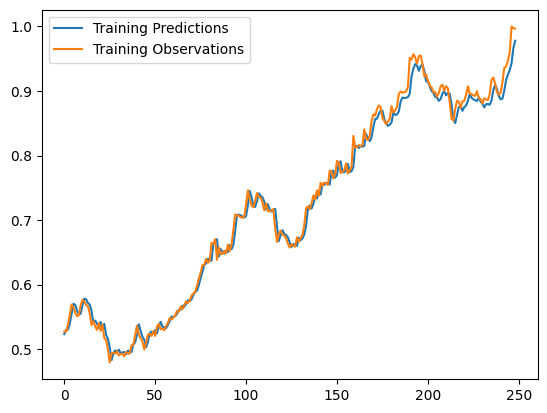

In [ ]:
#tests the model on unseen data

import matplotlib.pyplot as plt

test_predictions = model.predict(X_eval).flatten()

plt.plot(test_predictions)
plt.plot(Y_eval)
plt.legend(['Training Predictions', 'Training Observations'])